# ANALISIS RASCH

In [1]:
library(eRm) # digunakan untuk pemodelan rasch
library(dplyr) # dignakan untuk mengubah struktur data
library(readxl) # digunakan untuk membaca file excel
library(ggplot2) # digunakan untuk membuat grafik
library(tidyr) # digunakan untuk merapikan data
library(knitr)
library(psych)


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching package: ‘psych’

The following objects are masked from ‘package:ggplot2’:

    %+%, alpha

The following object is masked from ‘package:eRm’:

    sim.rasch



In [2]:
source("fungsi/plotICC.R")
source("fungsi/wrightmap2.R")
source("fungsi/treshold.R")
source("fungsi/rasch_item_diagnostics.R")
source("fungsi/tabel_distribusi_lrt.R")

In [3]:
data <- read_excel("data.xlsx") # membaca data menggunakan fungsi readxl dan menyimpannya di dataframe data
head(data, 5) # menampilkan 5 data teratas (mengecek apakah data sudah dibaca dengan benar oleh R)

# A tibble: 5 × 12
     S1    S2    S3    S4    S5    S6    S7    S8    S9   S10   S11   S12
  <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl>
1     3     3     1     3     3     3     0     3     3     4     4     3
2     3     3     1     4     2     3     2     2     2     3     2     2
3     2     3     1     2     0     3     4     2     2     1     2     3
4     2     3     1     3     0     1     0     4     3     1     2     3
5     3     4     1     4     1     2     0     0     2     4     3     2

## 1. Estimasi Parameter PCM

In [4]:
model_pcm <- PCM(data)

## 1. Validitas dan Reliabilitas Instrumen (Kualitas Soal)
### 1.1 Uji Unidimensionalitas

In [5]:
mloef_mean = MLoef(model_pcm, splitcr = "mean")
mloef_mean


Martin-Loef-Test (split criterion: mean)
LR-value: 184.706 
Chi-square df: 503 
p-value: 1 


### 1.2 Independensi Lokal (Local Item Independence)

In [6]:
# 1. HITUNG PARAMETER SISWA (WAJIB di eRm sebelum mencari residual)
estimasi_person <- person.parameter(model_pcm)

# 2. AMBIL RESIDUALNYA
# Fungsi ini dijalankan pada objek estimasi_person, bukan langsung pada model pcm
objek_res <- residuals(estimasi_person)

# 3. UBAH MENJADI MATRIKS NUMERIK
# Langkah ini penting agar struktur custom dari eRm berubah menjadi matriks angka murni
matriks_numerik <- as.matrix(objek_res)

# 4. HITUNG KORELASI RESIDUAL
cor_res <- cor(matriks_numerik, use = "pairwise.complete.obs")

# 5. TAMPILKAN HASILNYA
kable(round(cor_res, 3))



|    |     S1|     S2|     S3|     S4|     S5|     S6|     S7|     S8|     S9|    S10|    S11|    S12|
|:---|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|
|S1  |  1.000| -0.001|  0.133|  0.095|  0.028| -0.018| -0.291| -0.240| -0.208| -0.165|  0.124| -0.253|
|S2  | -0.001|  1.000| -0.095|  0.027|  0.024| -0.130| -0.167|  0.065|  0.018| -0.180| -0.246| -0.096|
|S3  |  0.133| -0.095|  1.000|  0.190|  0.047|  0.076| -0.274| -0.040| -0.007| -0.209|  0.058| -0.199|
|S4  |  0.095|  0.027|  0.190|  1.000| -0.159| -0.017| -0.158| -0.155| -0.177| -0.049| -0.176| -0.086|
|S5  |  0.028|  0.024|  0.047| -0.159|  1.000| -0.072| -0.090| -0.048| -0.116| -0.315| -0.099| -0.261|
|S6  | -0.018| -0.130|  0.076| -0.017| -0.072|  1.000| -0.084| -0.134| -0.255| -0.142|  0.072| -0.113|
|S7  | -0.291| -0.167| -0.274| -0.158| -0.090| -0.084|  1.000| -0.054| -0.155| -0.152| -0.392| -0.065|
|S8  | -0.240|  0.065| -0.040| -0.155| -0.048| -0.134| -0.054|  1.000| 

In [39]:
plot_residual_correlation <- function(cor_matrix) {
  
  library(ggplot2)
  library(dplyr)
  library(tidyr)
  
  # 1. Pastikan input berbentuk matriks murni
  cor_mat <- as.matrix(cor_matrix)
  item_order <- colnames(cor_mat)
  
  # 2. Transformasi dari matriks lebar ke bentuk Long Format (Tidy Data)
  df_long <- as.data.frame(cor_mat) %>%
    mutate(Item1 = rownames(.)) %>%
    pivot_longer(cols = -Item1, names_to = "Item2", values_to = "Correlation")
  
  # 3. FILTER SEGITIGA (LOWER TRIANGLE)
  # Menghapus informasi redundan di bagian kanan atas diagonal
  df_long <- df_long %>%
    mutate(
      idx1 = match(Item1, item_order),
      idx2 = match(Item2, item_order)
    ) %>%
    # Hanya pertahankan data di mana indeks X <= indeks Y (Segitiga Kiri Bawah)
    filter(idx1 <= idx2) %>%
    select(-idx1, -idx2)
  
  # 4. Atur struktur data agar diagonalnya berurutan dari kiri-atas ke kanan-bawah
  df_long <- df_long %>%
    mutate(
      Item1 = factor(Item1, levels = item_order),
      Item2 = factor(Item2, levels = rev(item_order)),
      
      # FLAG: Tandai jika korelasi > 0.20 dan BUKAN garis diagonal (Item1 != Item2)
      Flag = ifelse(Item1 != Item2 & Correlation > 0.20, "Violation", "Normal"),
      
      # Hilangkan nilai korelasi diagonal khusus untuk warna latar (fill) agar tetap putih bersih
      Fill_Value = ifelse(Item1 == Item2, NA, Correlation)
    )
  
  # 5. Pembuatan Plot Utama
  p <- ggplot(df_long, aes(x = Item1, y = Item2)) +
    
    # Base Heatmap: Kotak korelasi dengan garis batas abu-abu sangat tipis
    geom_tile(aes(fill = Fill_Value), colour = "black", linewidth = 0.3) +
    
    # Overlay Bingkai Merah: Hanya digambar pada sel yang melanggar korelasi > 0.20
    geom_tile(
      data = filter(df_long, Flag == "Violation"),
      aes(x = Item1, y = Item2),
      fill = NA,
      colour = "#C0392B",  # Merah crimson pekat standar jurnal ilmiah
      linewidth = 1.0      # Garis bingkai dibuat tebal agar mencolok
    ) +
    
    # Menampilkan Angka Korelasi di dalam Kotak
    geom_text(
      aes(
        label = sprintf("%.2f", Correlation),
        colour = Flag,
        fontface = ifelse(Flag == "Violation" | Item1 == Item2, "bold", "bold")
      ),
      size = 5
    ) +
    
    # Pengaturan Warna Teks Angka (Merah jika melanggar, Hitam jika aman)
    scale_colour_manual(
      values = c("Violation" = "#C0392B", "Normal" = "#88b24b"),
      guide = "none"
    ) +
    
    # Skala Warna Latar Belakang (Sangat minim warna, putih ke abu-abu gelap)
    scale_fill_gradient2(
      low = "grey90",       
      mid = "#FAFAFA",      
      high = "grey30",      
      midpoint = 0,
      na.value = "white",   
      name = "Residual\nCorrelation",
      limits = c(-1, 1)
    ) +
    
    labs(
      # title = "Item Residual Correlation Matrix",
      # subtitle = "Red frames highlight local dependency violations (r > 0.20)",
      x = NULL,
      y = NULL
    ) +
    
    # Pengaturan Tema Putih Bersih (Clean White Background)
    theme_minimal(base_size = 12) +
    theme(
      axis.text.x = element_text(angle = 0, vjust = 1, hjust = 1, face = "bold", colour = "black"),
      axis.text.y = element_text(face = "bold", colour = "black"),
      panel.grid = element_blank(),
      plot.title = element_text(face = "bold", size = 14, colour = "black"),
      # plot.subtitle = element_text(size = 11, colour = "green"),
      legend.title = element_text(face = "bold", size = 12),
      legend.position = "right",
      # Karena sebagian plot sekarang kosong, background putih akan membuatnya terlihat bersih
      plot.background = element_rect(fill = "white", colour = NA),
      panel.background = element_rect(fill = "white", colour = NA)
    )
  
  return(p)
}

In [64]:
plot_residual_correlation2 <- function(cor_matrix) {
  
  library(ggplot2)
  library(dplyr)
  library(tidyr)
  
  # 1. Pastikan input berbentuk matriks murni
  cor_mat <- as.matrix(cor_matrix)
  item_order <- colnames(cor_mat)
  
  # 2. Transformasi dari matriks lebar ke bentuk Long Format (Tidy Data)
  df_long <- as.data.frame(cor_mat) %>%
    mutate(Item1 = rownames(.)) %>%
    pivot_longer(cols = -Item1, names_to = "Item2", values_to = "Correlation")
  
  # 3. FILTER SEGITIGA (LOWER TRIANGLE)
  # Menghapus informasi redundan di bagian kanan atas diagonal
  df_long <- df_long %>%
    mutate(
      idx1 = match(Item1, item_order),
      idx2 = match(Item2, item_order)
    ) %>%
    # Hanya pertahankan data di mana indeks X <= indeks Y (Segitiga Kiri Bawah)
    filter(idx1 <= idx2) %>%
    select(-idx1, -idx2)
  
  # 4. Atur struktur data agar diagonalnya berurutan dari kiri-atas ke kanan-bawah
  df_long <- df_long %>%
    mutate(
      Item1 = factor(Item1, levels = item_order),
      Item2 = factor(Item2, levels = rev(item_order)),
      
      # FLAG: Tandai jika korelasi > 0.20 dan BUKAN garis diagonal (Item1 != Item2)
      Flag = ifelse(Item1 != Item2 & Correlation > 0.20, "Violation", "Normal"),
      
      # Hilangkan nilai korelasi diagonal khusus untuk warna latar (fill) agar tetap putih bersih
      Fill_Value = ifelse(Item1 == Item2, NA, Correlation)
    )
  
  # 5. Pembuatan Plot Utama
  p <- ggplot(df_long, aes(x = Item1, y = Item2)) +
    
    # Base Heatmap: Kotak korelasi dengan garis batas abu-abu sangat tipis
    geom_tile(aes(fill = Fill_Value), colour = "grey50", linewidth = 0.3) +
    
    # Overlay Bingkai Merah: Hanya digambar pada sel yang melanggar korelasi > 0.20
    geom_tile(
      data = filter(df_long, Flag == "Violation"),
      aes(x = Item1, y = Item2),
      fill = NA,
      colour = "#C0392B",  # Merah crimson pekat standar jurnal ilmiah
      linewidth = 1.0      # Garis bingkai dibuat tebal agar mencolok
    ) +
    
    # Menampilkan Angka Korelasi di dalam Kotak
    geom_text(
      aes(
        label = sprintf("%.2f", Correlation),
        colour = Flag,
        fontface = ifelse(Flag == "Violation" | Item1 == Item2, "bold", "plain")
      ),
      size = 5
    ) +
    
    # Pengaturan Warna Teks Angka (Merah jika melanggar, Hitam jika aman)
    scale_colour_manual(
      values = c("Violation" = "#C0392B", "Normal" = "#88b24b"),
      guide = "none"
    ) +
    
    # Skala Warna Latar Belakang (Sangat minim warna, putih ke abu-abu gelap)
    scale_fill_gradient2(
      low = "grey90",        
      mid = "#FAFAFA",      
      high = "grey30",      
      midpoint = 0,
      na.value = "white",   
      name = "Residual\nCorrelation",
      limits = c(-1, 1)
    ) +
    
    labs(
      # title = "Item Residual Correlation Matrix",
      # subtitle = "Red frames highlight local dependency violations (r > 0.20)",
      x = NULL,
      y = NULL
    ) +
    
    # Pengaturan Tema Putih Bersih (Clean White Background)
    theme_minimal(base_size = 16) +
    theme(
      axis.text.x = element_text(angle = 0, vjust = 1, hjust = 1, face = "plain", colour = "black"),
      axis.text.y = element_text(face = "plain", colour = "black"),
      panel.grid = element_blank(),
      plot.title = element_text(face = "bold", size = 14, colour = "black"),
      # plot.subtitle = element_text(size = 11, colour = "green"),
      legend.title = element_text(face = "bold", size = 12),
      legend.position = "right",
      # Karena sebagian plot sekarang kosong, background putih akan membuatnya terlihat bersih
      plot.background = element_rect(fill = "white", colour = NA),
      panel.background = element_rect(fill = "white", colour = NA),
      
      # TAMBAHAN: Garis kotak lembut yang mengelilingi area panel plot
      panel.border = element_rect(colour = "grey30", fill = NA, linewidth = 1)
    )
  
  return(p)
}

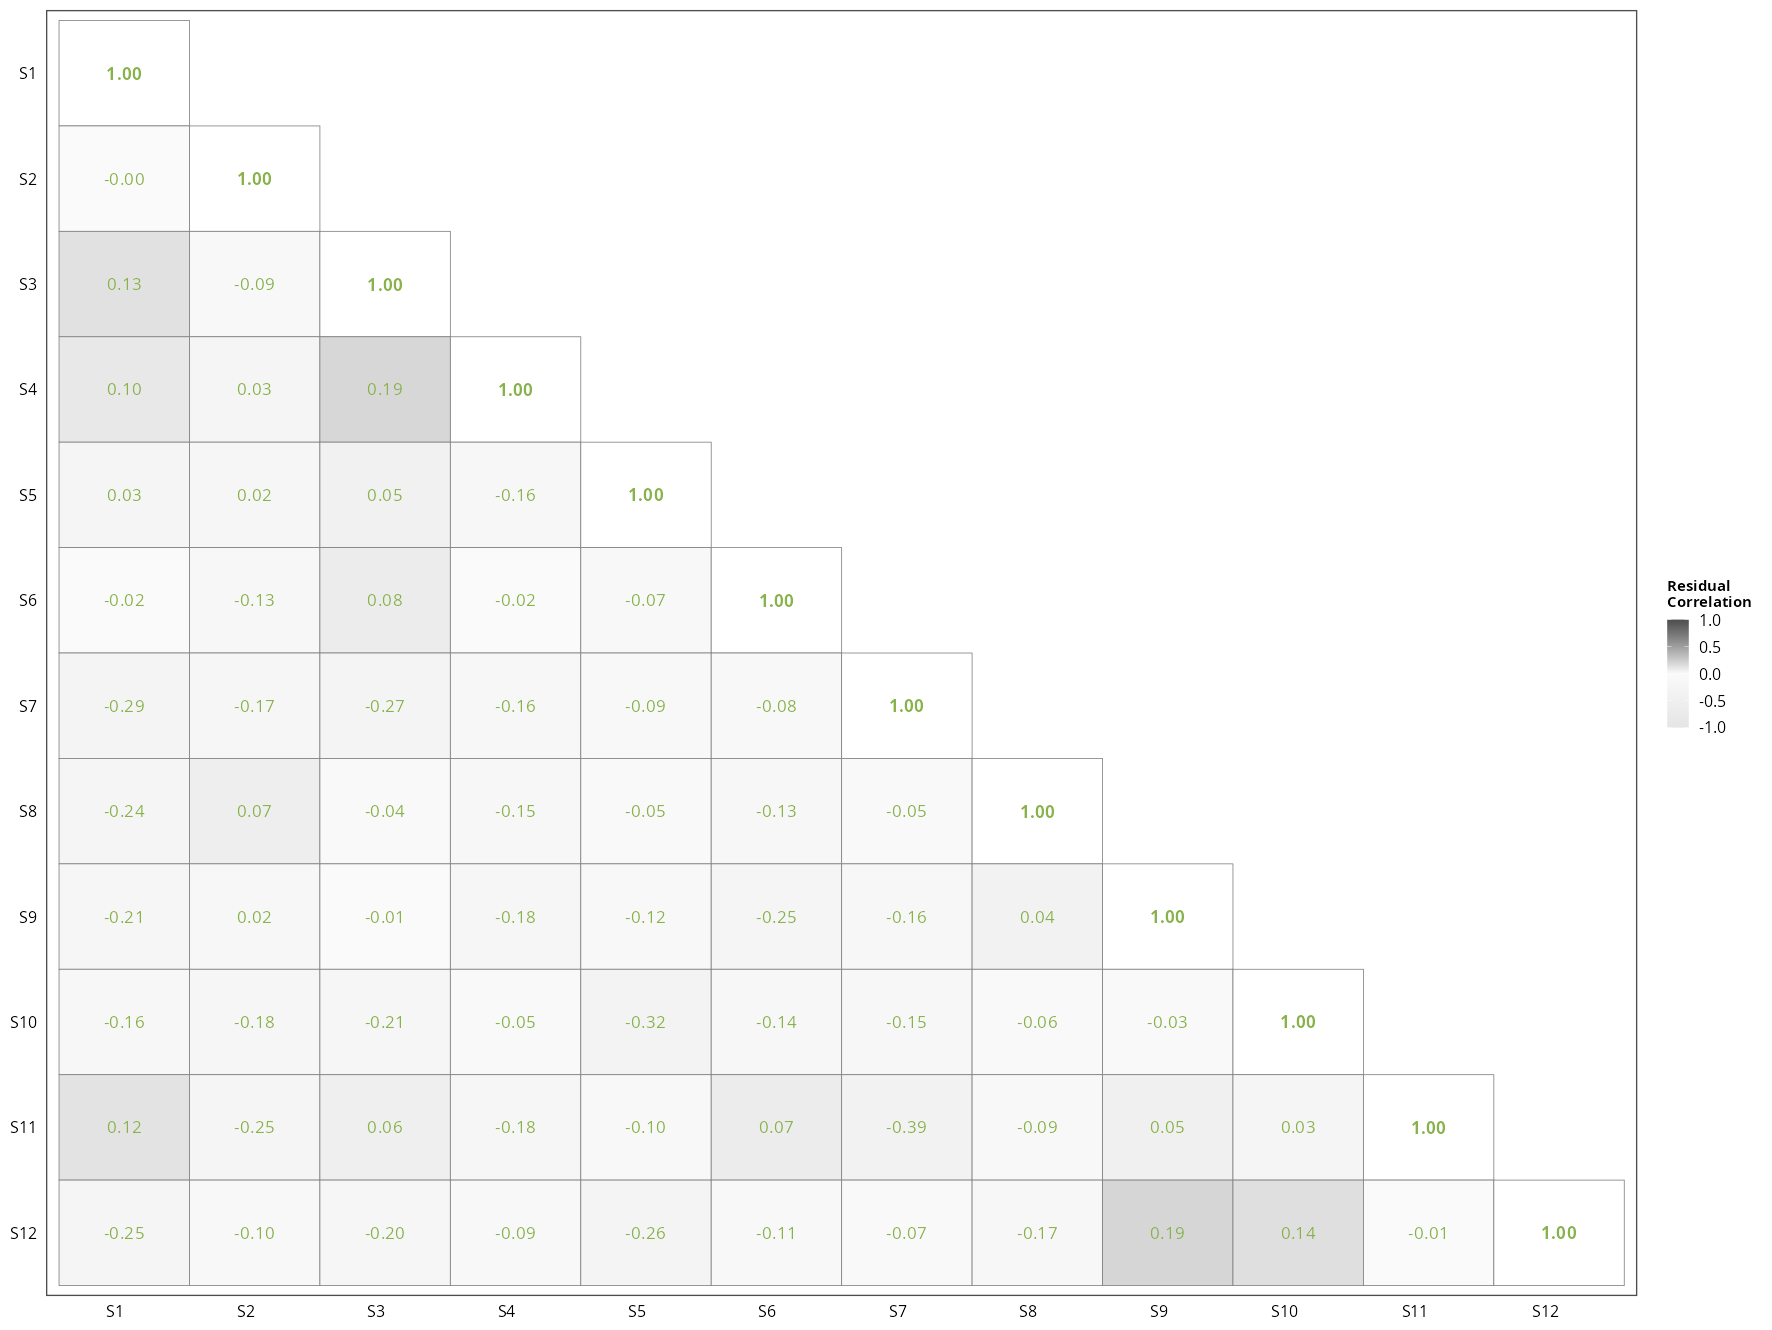

In [65]:
# Panggil fungsi untuk memunculkan plot korelasi residual Anda
matrix_corr <- plot_residual_correlation2(cor_res)
matrix_corr

In [66]:
ggsave('plot/matrix_corr.png', width = 10, height = 8, units = "in", dpi = 1200)

### 1.3 Item Fit (Kesesuaian Butir Soal)

In [14]:
item_fit <- itemfit(person.parameter(model_pcm))
item_fit


Itemfit Statistics: 
      Chisq  df p-value Outfit MSQ Infit MSQ Outfit t Infit t Discrim
S1   76.388 101   0.968      0.749     0.785   -1.909  -2.282   0.606
S2   93.314 101   0.694      0.915     0.962   -0.521  -0.204   0.249
S3   90.663 101   0.760      0.889     0.914   -0.944  -0.724   0.432
S4  101.708 101   0.462      0.997     0.994    0.018  -0.014   0.276
S5  108.038 101   0.298      1.059     1.050    0.517   0.458   0.215
S6   96.788 101   0.600      0.949     0.916   -0.258  -0.538   0.347
S7  179.973 101   0.000      1.764     1.429    3.980   3.445  -0.041
S8  100.127 101   0.506      0.982     0.994   -0.032   0.030   0.106
S9   75.659 101   0.972      0.742     0.778   -1.618  -1.389   0.529
S10  82.940 101   0.905      0.813     0.800   -1.438  -1.809   0.530
S11  73.544 101   0.982      0.721     0.724   -2.576  -2.589   0.665
S12  88.530 101   0.808      0.868     0.877   -0.892  -0.955   0.422


### 1.4 Item Reliability & Separation Index

In [20]:
# reliabilitas item
# eRm menyimpan parameter item di $betapar sebagai nilau easiness. 
# mengalikannya dengan -1 mengubahnya menjadi kesukaran.
item_difficulties <- -1 * model_pcm$betapar

# Mengekstrak nilai SE masing2 parameter item
item_se <- model_pcm$se.beta

# menghitung varians item dan mean error variance
observed_item_var   <- var(item_difficulties)
mean_item_error_var <- mean(item_se^2)

# mengaplikasikan reliabilitas item rasch: (Observed Var - Error Var) / Observed Var
item_reliability <- (observed_item_var - mean_item_error_var) / observed_item_var

# menampilkan hasil
cat("Item Reliability (Separation)  : ", round(item_reliability, 3), "\n")


Item Reliability (Separation)  :  0.905 


### 1.5 Fungsi Kategori Skor (Threshold/Category Functioning)

In [19]:
thresholds(model_pcm)


Design Matrix Block 1:
    Location Threshold 1 Threshold 2 Threshold 3 Threshold 4
S1   1.13996     2.14635    -0.61988    -1.13939     4.17276
S2  -0.26814    -0.72817    -1.61408    -0.21779     1.48748
S3   1.70287     0.44718     2.95857          NA          NA
S4  -0.08668    -2.91431     0.30488     0.52865     1.73406
S5   0.64538     0.04046     0.18169     0.74833     1.61105
S6  -0.02914    -0.54046    -0.52178    -0.98036     1.92603
S7   0.29946     3.84541    -2.83638     1.30301    -1.11422
S8   0.21198     1.26632    -3.50799     2.05951     1.03006
S9   0.14619     1.08858    -3.16922     0.56570     2.09971
S10 -0.03455     0.05970    -0.10812    -0.23645     0.14665
S11  0.20022    -0.42339    -0.18102     0.49899     0.90629
S12  0.19040    -1.16204     0.26086    -1.05675     2.71951


## 2. Hasil Utama Penelitian (Profil Kemampuan Siswa)

### 2.1 Person Reliability & Separation Index

In [68]:
# reliabilitas person
p_rel_obj   <- SepRel(estimasi_person)
person_reliability <- p_rel_obj$sep.rel

cat("Person Reliability (Separation)  : ", round(person_reliability, 3), "\n")

Person Reliability (Separation)  :  0.62 


### 2.2 Person-Item Map (Wright Map)

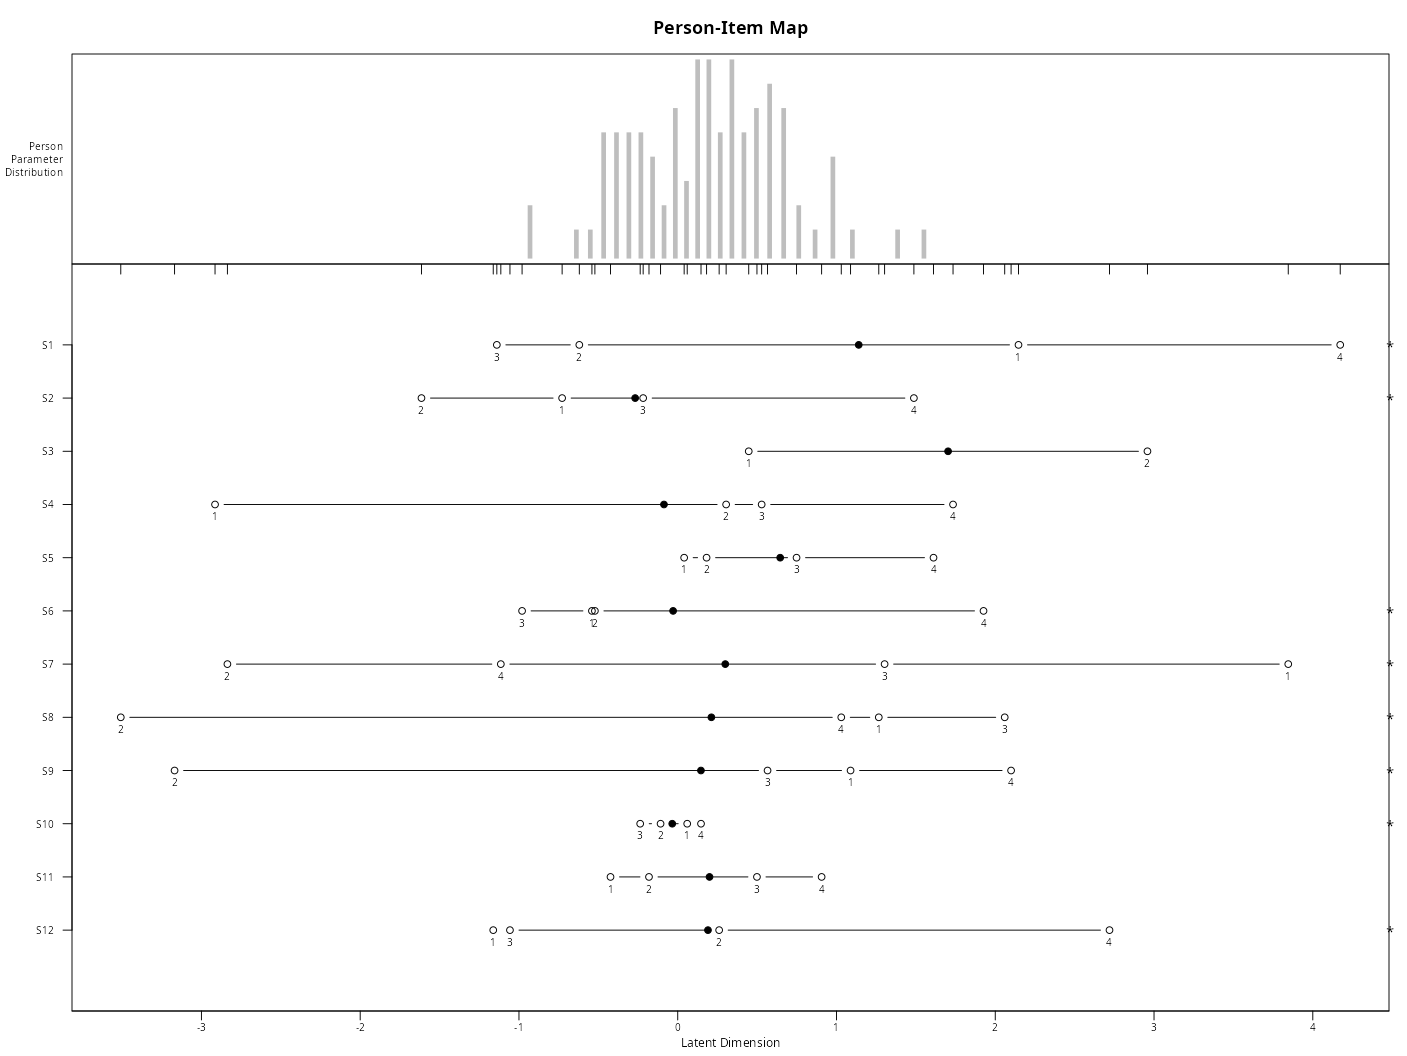

In [69]:
plotPImap(model_pcm)

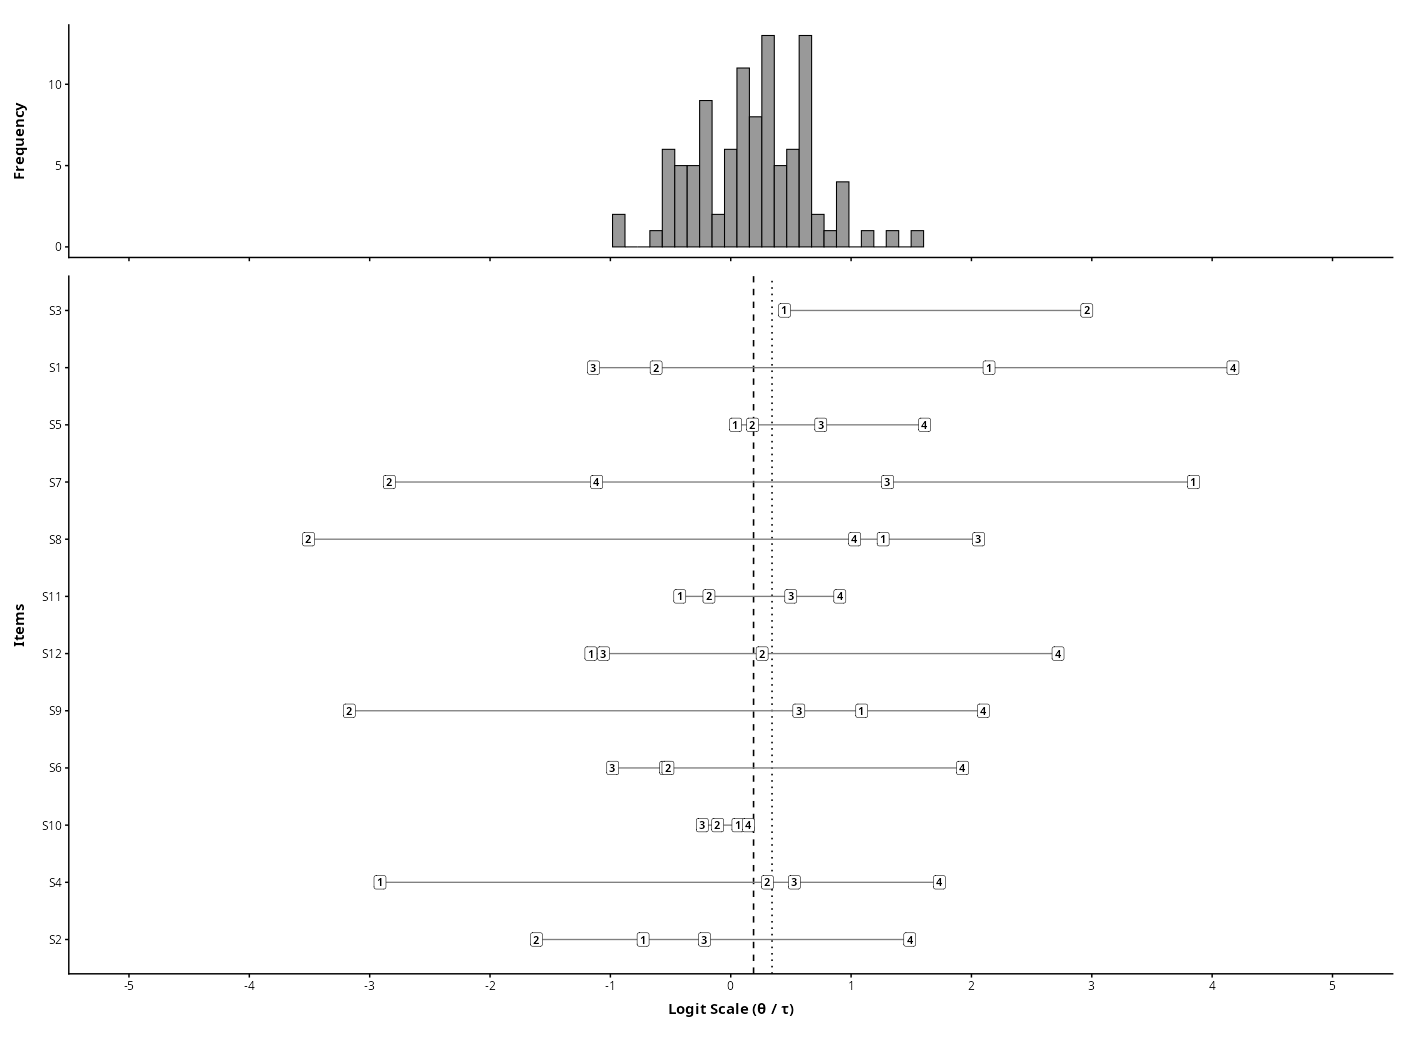

In [72]:
source("fungsi/treshold.R")
treshold_map <- plot_threshold_map(model_pcm)
treshold_map

In [24]:
ggsave('plot/treshold_map.png', treshold_map, width = 10, height=8, dpi=1200, units = "in")

### 3.2 Person Measure (Skor Logit Kemampuan Siswa)

In [25]:
# Summarize person parameters
summary(estimasi_person)


Estimation of Ability Parameters

Collapsed log-likelihood: -333.3505 
Number of iterations: 8 
Number of parameters: 25 

ML estimated ability parameters (without spline interpolated values): 
              Estimate Std. Err.        2.5 %      97.5 %
theta P1    0.97725925 0.3424443  0.306080736  1.64843777
theta P2    0.57895229 0.2925880  0.005490324  1.15241425
theta P3    0.26784732 0.2690112 -0.259404847  0.79509949
theta P4    0.12552576 0.2652786 -0.394410661  0.64546218
theta P5    0.34115479 0.2727220 -0.193370521  0.87568010
theta P6    0.19619099 0.2665656 -0.326268037  0.71865001
theta P7   -0.38571501 0.2816907 -0.937818696  0.16638867
theta P8   -0.01515017 0.2657973 -0.536103287  0.50580295
theta P9    0.57895229 0.2925880  0.005490324  1.15241425
theta P10   0.19619099 0.2665656 -0.326268037  0.71865001
theta P11   0.66739248 0.3024696  0.074563048  1.26022192
theta P12   0.34115479 0.2727220 -0.193370521  0.87568010
theta P13   0.05525876 0.2650517 -0.464233038  0.57

In [38]:
plot_score_theta <- function(model_object) {
  
  # Pastikan package ini sudah di-install dan di-load
  library(ggplot2)
  library(ggExtra) 
  library(dplyr)
  
  # =====================================
  # 1. EKSTRAKSI DATA
  # =====================================
  
  # Mengambil nilai Person Ability (Theta)
  pp <- person.parameter(model_object)
  theta <- as.numeric(pp$theta.table[, "Person Parameter"])
  
  # Mengambil Raw Score (Total Skor) dari matriks data asli
  raw_score <- rowSums(model_object$X, na.rm = TRUE)
  
  # Gabungkan menjadi data frame
  df <- data.frame(
    RawScore = raw_score, 
    Theta = theta
  )
  
  # =====================================
  # 2. HITUNG STATISTIK KORELASI
  # =====================================
  
  cor_res <- cor.test(df$RawScore, df$Theta, method = "pearson")
  r_val <- cor_res$estimate
  p_val <- cor_res$p.value
  
  # Memperbaiki format p-value agar rapi (misal: p < 0.001)
  p_text <- ifelse(p_val < 0.001, "p < 0.001", sprintf("p = %.3f", p_val))
  stats_label <- sprintf("Pearson r = %.2f | %s", r_val, p_text)
  
  # =====================================
  # 3. BUAT PLOT UTAMA (SCATTER PLOT)
  # =====================================
  
  p_main <- ggplot(df, aes(x = RawScore, y = Theta)) +
    
    # Titik-titik scatter
    geom_point(colour = "black", alpha = 0.5, size = 2) +
    
    # Garis tren (menggunakan polinomial derajat 2 agar ada sedikit lengkungan natural seperti di gambar)
    geom_smooth(
      method = "lm", 
      formula = y ~ poly(x, 2), 
      colour = "black", 
      fill = "grey85", # Warna pita standar eror
      linewidth = 1
    ) +
    
    labs(
      x = "Total Score",
      y = "Person Ability (θ, logit)",
      title = "Correlation between Total Score and Person Ability",
      subtitle = stats_label
    ) +
    
    theme_classic(base_size = 12) +
    
    theme(
      plot.background = element_rect(fill = "white", colour = NA),
      panel.background = element_rect(fill = "white", colour = NA),
      axis.title.x = element_text(face = "bold", colour = "black", margin = margin(t = 12)),
      axis.title.y = element_text(face = "bold", colour = "black", margin = margin(r = 12)),
      axis.text = element_text(colour = "black"),
      plot.title = element_text(face = "bold", size = 14, colour = "black"),
      plot.subtitle = element_text(size = 11, colour = "grey20", face = "italic"),
      plot.margin = margin(t = 10, r = 10, b = 10, l = 10)
    )
  
  # =====================================
  # 4. TAMBAHKAN GRAFIK MARGINAL
  # =====================================
  
  # Fungsi ggMarginal akan secara otomatis menempelkan distribusi di pinggir plot utama
  p_final <- ggExtra::ggMarginal(
    p_main,
    type = "densigram",      # "densigram" menggabungkan histogram & kurva kepadatan (density)
    fill = "grey60",         # Warna batang histogram seragam dengan plot kita sebelumnya
    colour = "black",        # Garis tepi batang
    alpha = 0.7,
    linewidth = 0.3,
    margins = "both"         # Pasang di sumbu X dan Y
  )
  
  return(p_final)
}

## correlation between total score and person ability

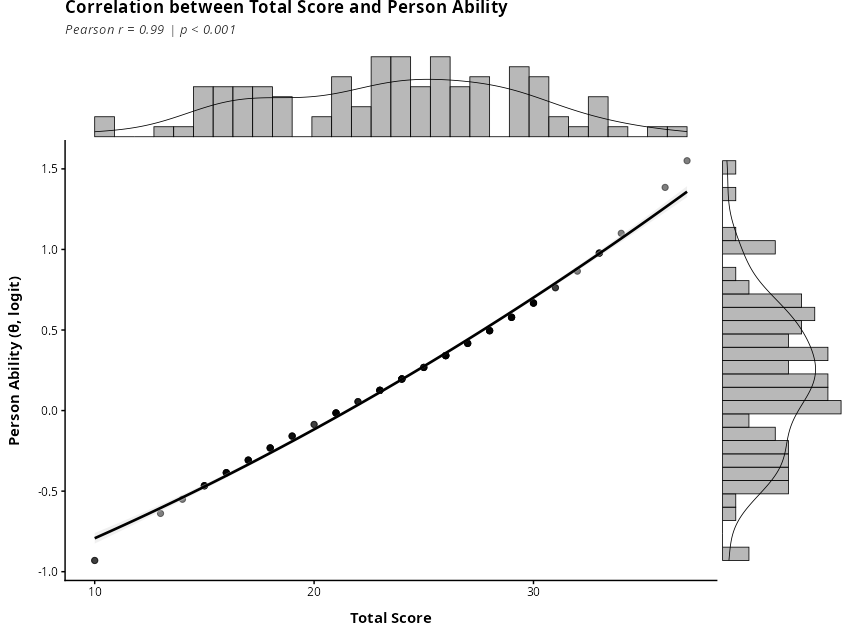

In [39]:
# Memanggil fungsi
plot_korelasi <- plot_score_theta(model_pcm)

# Menampilkan grafik
print(plot_korelasi)

In [41]:
# 1. Ekstraksi data dari model pcm Anda
pp_obj <- person.parameter(model_pcm)

df_perbandingan <- data.frame(
  Siswa_ID   = paste0("Siswa_", 1:nrow(model_pcm$X)),
  Total_Skor = rowSums(model_pcm$X, na.rm = TRUE),
  Logit_Theta = as.numeric(pp_obj$theta.table[, "Person Parameter"])
)

# 2. Tampilkan 10 baris pertama di konsol R untuk pengecekan
df_perbandingan

      Siswa_ID Total_Skor Logit_Theta
P1     Siswa_1         33  0.97725925
P2     Siswa_2         29  0.57895229
P3     Siswa_3         25  0.26784732
P4     Siswa_4         23  0.12552576
P5     Siswa_5         26  0.34115479
P6     Siswa_6         24  0.19619099
P7     Siswa_7         16 -0.38571501
P8     Siswa_8         21 -0.01515017
P9     Siswa_9         29  0.57895229
P10   Siswa_10         24  0.19619099
P11   Siswa_11         30  0.66739248
P12   Siswa_12         26  0.34115479
P13   Siswa_13         22  0.05525876
P14   Siswa_14         27  0.41685831
P15   Siswa_15         19 -0.15834807
P16   Siswa_16         31  0.76234696
P17   Siswa_17         26  0.34115479
P18   Siswa_18         21 -0.01515017
P19   Siswa_19         26  0.34115479
P20   Siswa_20         29  0.57895229
P21   Siswa_21         23  0.12552576
P22   Siswa_22         26  0.34115479
P23   Siswa_23         31  0.76234696
P24   Siswa_24         24  0.19619099
P25   Siswa_25         33  0.97725925
P26   Siswa_

In [46]:
# ==============================================================================
# DESCRIPTIVE STATISTICS PIPELINE FOR RASCH ANALYSIS (FIXED)
# ==============================================================================

library(dplyr)

# 1. Extract Latent Traits and Observed Scores
pp_obj <- person.parameter(model_pcm)

df_metrics <- data.frame(
  Observed_Score = rowSums(model_pcm$X, na.rm = TRUE),
  Latent_Trait   = as.numeric(pp_obj$theta.table[, "Person Parameter"])
)

# 2. Build the Transposed Table Directly Row-by-Row
# This avoids string-splitting bugs entirely
descriptive_table <- data.frame(
  `Statistical Metric` = c(
    "N", 
    "Minimum", 
    "Q1 (25th Percentile)", 
    "Median", 
    "Mean", 
    "Q3 (75th Percentile)", 
    "Maximum", 
    "SD (Standard Deviation)"
  ),
  
  `Total Raw Score` = c(
    sum(!is.na(df_metrics$Observed_Score)),
    min(df_metrics$Observed_Score, na.rm = TRUE),
    quantile(df_metrics$Observed_Score, 0.25, na.rm = TRUE),
    median(df_metrics$Observed_Score, na.rm = TRUE),
    mean(df_metrics$Observed_Score, na.rm = TRUE),
    quantile(df_metrics$Observed_Score, 0.75, na.rm = TRUE),
    max(df_metrics$Observed_Score, na.rm = TRUE),
    sd(df_metrics$Observed_Score, na.rm = TRUE)
  ),
  
  `Person Location (θ)` = c(
    sum(!is.na(df_metrics$Latent_Trait)),
    min(df_metrics$Latent_Trait, na.rm = TRUE),
    quantile(df_metrics$Latent_Trait, 0.25, na.rm = TRUE),
    median(df_metrics$Latent_Trait, na.rm = TRUE),
    mean(df_metrics$Latent_Trait, na.rm = TRUE),
    quantile(df_metrics$Latent_Trait, 0.75, na.rm = TRUE),
    max(df_metrics$Latent_Trait, na.rm = TRUE),
    sd(df_metrics$Latent_Trait, na.rm = TRUE)
  ),
  
  check.names = FALSE # Prevents R from converting spaces to dots in column headers
)

# 3. Apply Decimal Precision Rounding to Numeric Columns Safely
descriptive_table$`Total Raw Score` <- round(descriptive_table$`Total Raw Score`, 3)
descriptive_table$`Person Location (θ)` <- round(descriptive_table$`Person Location (θ)`, 3)

# 4. Render Structural 
descriptive_table

       Statistical Metric Total Raw Score Person Location (θ)
1                       N         102.000             102.000
2                 Minimum          10.000              -0.930
3    Q1 (25th Percentile)          19.000              -0.158
4                  Median          24.000               0.196
5                    Mean          23.657               0.190
6    Q3 (75th Percentile)          28.000               0.496
7                 Maximum          37.000               1.551
8 SD (Standard Deviation)           5.823               0.465

| Komponen Analisis Rasch (PCM) | Nilai | Kriteria Ideal | Status / Kesimpulan |
|-------------------------------|--------------|----------------|----------------------|
| Martin-Löf Test (p-value)     | 1.0  | > 0.05         | Unidimensional (Lolos) |
| Item Reliability              | 0.92  | > 0.70         | Bagus / Konsisten     |
| Person Reliability            | 0.62         | > 0.70         | Moderat (Siswa Homogen) |
| Item Fit (Infit/Outfit MNSQ)  | [Rentang Nilai] | 0.5 - 1.5    | Semua soal Fit        |
| Local Independence (r Residual) | < 0.20      | < 0.20         | Tidak ada dependensi / Lolos |